# 4.9. Panorama-Assisted Labeling

Notebook 4 finds fixed obstacles (trees, street lights, cars, benches, ...)
via BGT/Bomen-Atlas matching and leaves whatever DBSCAN clusters it can't
match as `label == 0` ("Unknown"). Since the 2025 point clouds and 2025
panoramas were captured essentially simultaneously (no temporal mismatch
this time), this notebook uses same-day panorama YOLO detections to
*suggest* a label for those Unknown clusters.

Suggestions are **not** trusted automatically: they're written into
`label` / `label_frac` / `label_source` (not `final_label`), landing them
in `4.5. Enhanced Labeling Review.ipynb`'s existing "Review" mode — a
suggested label shown for one-click confirm or override, same as a weak
BGT auto-label.

**Run after:** `2. Ground and Road fusion.ipynb` -> `4. Auto-Labeling
Pipeline.ipynb` (needs `inventory_<tilecode>.csv` to exist).
**Run before:** `4.5. Enhanced Labeling Review.ipynb`.

In [ ]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, str(Path.cwd()))
import config
from utils.labels import Labels
from utils.panorama_api import fetch_panoramas_in_tile, download_panorama_image
from utils.panorama_geometry import (
    CameraPose, make_patches, equirect_to_perspective,
    detection_to_ray, ray_ground_intersect,
)
from utils.detection import (
    load_detector, detect_patches, label_clusters_from_panorama, resolve_shared_claims,
)
from utils.triangulation import triangulate_detections, correct_camera_elevation
from utils.ahn_reader import PolygonNPZReader
from utils.cluster_io import build_cluster_inventory

## Configuration

In [ ]:
tilecodes = [tc for tc in config.SETUP_TILECODES
             if tc in config.tilecodes_in_dir(config.TILE_DIR)]
print(f"{len(tilecodes)}/{len(config.SETUP_TILECODES)} SETUP_TILECODES have raw data under {config.TILE_DIR}:")
print(" ", tilecodes)

PANO_YEAR      = 2025   # panoramas and point clouds captured the same year
PANO_DIR       = Path("data/input/panoramas")
YOLO_WEIGHTS   = "yolov8m.pt"
DETECTION_CONF = 0.35
CAM_HEIGHT_M   = 2.0
MIN_SPACING_M  = 4.0    # tested on tile 119900_489300 against the previous 8.0m:
                         # 13->25 panoramas, 28->43 distinct objects triangulated
                         # from >=2 camera views (+54%), for 2x fetch/detection
                         # time and image cache size. Cyclomedia frames are ~5m
                         # apart, so 4m is close to the floor -- little headroom
                         # left by going lower.
BUFFER_M       = 30.0
IMAGE_SIZE     = "medium"
FORCE_REFETCH  = False

MATCH_RADIUS_M = 3.0    # LiDAR cluster <-> panorama detection match radius,
                         # matches the MATCH_R_M_BGT convention used elsewhere
MIN_BASELINE_M = 3.0    # min camera separation to attempt triangulation
MAX_RESIDUAL_M = 1.5    # max RMS ray residual to accept a triangulation

N_PATCHES  = 4
FOV_H      = 90.0
PATCH_SIZE = (640, 640)

print(f"Panorama year: {PANO_YEAR}")

## Step 1 — Fetch panoramas + detect + triangulate

Single epoch — no multi-year loop needed, unlike the older sidewalk-width
work, since 2025 panoramas and point clouds share the same capture date.

In [ ]:
model = load_detector(YOLO_WEIGHTS)
ahn_reader = PolygonNPZReader(config.AHN_NPZ_DIR)

DETECTIONS_BY_TILE = {}
CAM_RESULTS_BY_TILE = {}   # kept alongside the flat detections list --
                           # resolve_shared_claims() (Step 2) needs the
                           # per-camera bbox/patch_idx/pose that produced
                           # each detection, not just its final x_rd/y_rd.

for tilecode in tilecodes:
    tile_pano_dir = PANO_DIR / tilecode
    tile_pano_dir.mkdir(parents=True, exist_ok=True)
    # Year-specific filename — notebooks 8/9 cache to a plain "panoramas.json"
    # (whatever mission_year they were last run with), which would otherwise
    # get silently reused here regardless of PANO_YEAR.
    cache_path = tile_pano_dir / f"panoramas_{PANO_YEAR}.json"

    if cache_path.exists() and not FORCE_REFETCH:
        with open(cache_path) as f:
            poses = json.load(f)
        print(f"  {tilecode}: {len(poses)} panoramas (cached, {PANO_YEAR})")
    else:
        poses = fetch_panoramas_in_tile(
            tilecode, bbox_dir=config.BBOX_DIR, mission_year=PANO_YEAR,
            min_spacing_m=MIN_SPACING_M, buffer_m=BUFFER_M,
        )
        if poses:
            for pose in poses:
                download_panorama_image(pose, size=IMAGE_SIZE, cache_dir=tile_pano_dir)
            with open(cache_path, "w") as f:
                json.dump(poses, f, indent=2)
        print(f"  {tilecode}: {len(poses)} panoramas fetched ({PANO_YEAR})")

    if not poses:
        DETECTIONS_BY_TILE[tilecode] = []
        CAM_RESULTS_BY_TILE[tilecode] = []
        continue

    cam_results = []
    for pose_d in poses:
        cam_pose = CameraPose(
            x_rd=pose_d["x_rd"], y_rd=pose_d["y_rd"], z=pose_d["z_wgs84"],
            heading=pose_d["heading"], pitch=pose_d["pitch"],
            roll=pose_d.get("roll", 0.0),
        )
        img_p = tile_pano_dir / f"{pose_d['pano_id']}.jpg"
        if not img_p.exists():
            continue

        img_i = np.array(Image.open(img_p).convert("RGB"))
        pps = make_patches(
            heading_deg=cam_pose.heading, fov_h_deg=FOV_H,
            out_hw=PATCH_SIZE, n_horizontal=N_PATCHES,
            pitch_deg=0.0, img_shape=img_i.shape,
        )
        patches_i = [equirect_to_perspective(img_i, pp) for pp in pps]
        dets_i    = detect_patches(patches_i, pps, model, conf=DETECTION_CONF)

        correct_camera_elevation(cam_pose, ahn_reader, tilecode, cam_height_m=CAM_HEIGHT_M)

        gz = cam_pose.z - CAM_HEIGHT_M
        for det in dets_i:
            x1, y1, x2, y2 = det.bbox_xyxy
            # was (x1, y2, x2, y2) -- dropped y1 entirely, duplicating the
            # box's bottom edge into both y-coordinates. cx_patch (azimuth)
            # only reads x1/x2 so direction was unaffected, but cy_patch
            # (elevation) came out as the box's bottom edge instead of its
            # centre, skewing the ray's elevation and hence the flat-ground
            # distance estimate -- confirmed distorting which detection came
            # out "nearest" for at least one real cluster match.
            origin, ray = detection_to_ray((x1, y1, x2, y2), pps[det.patch_idx], cam_pose)
            det.ray_origin = tuple(origin)
            det.ray_dir    = tuple(ray)
            result = ray_ground_intersect(cam_pose, ray, gz)
            if result is not None:
                det.x_rd, det.y_rd = result
                det.x_rd_single, det.y_rd_single = result

        valid = [d for d in dets_i if d.x_rd is not None]
        cam_results.append((pose_d, cam_pose, valid))

    if cam_results:
        triangulate_detections(
            cam_results, tilecode, ahn_reader,
            match_radius_m=MATCH_RADIUS_M, min_baseline_m=MIN_BASELINE_M,
            max_residual_m=MAX_RESIDUAL_M, cam_height_m=CAM_HEIGHT_M,
        )

    all_dets = [d for _, _, dets in cam_results for d in dets]
    DETECTIONS_BY_TILE[tilecode] = all_dets
    CAM_RESULTS_BY_TILE[tilecode] = cam_results
    print(f"    -> {len(cam_results)} cameras, {len(all_dets)} detections")

## Step 2 — Label previously-Unknown clusters from panorama detections

In [4]:

# label_clusters_from_panorama() only touches rows where label == 0, so it
# never overwrites a label a human has already confirmed via 4.5 (final_label
# set). But that also means a *previous* run's panorama_yolo suggestions
# don't get revisited on re-run — they're no longer label == 0, even if this
# run has better inputs (fixed 2025 panorama cache, size-plausibility guard).
# Reset only the unconfirmed ones (final_label still empty) back to Unknown
# so they're eligible to be re-evaluated below.
N_RESET = 0
for tilecode in tilecodes:
    inv_path = config.CLUSTERS_DIR / f"inventory_{tilecode}.csv"
    if not inv_path.exists():
        continue
    inv = pd.read_csv(inv_path)
    reset_mask = (inv["label_source"] == "panorama_yolo") & inv["final_label"].isna()
    n = int(reset_mask.sum())
    if n:
        inv.loc[reset_mask, "label"] = 0
        inv.loc[reset_mask, "label_frac"] = 0.0
        inv.loc[reset_mask, "label_source"] = "unknown"
        inv.to_csv(inv_path, index=False)
    N_RESET += n
    print(f"  {tilecode}: reset {n} unconfirmed panorama_yolo rows back to Unknown")
print(f"\nTotal reset: {N_RESET}")


  120300_489300: reset 0 unconfirmed panorama_yolo rows back to Unknown
  120300_488900: reset 0 unconfirmed panorama_yolo rows back to Unknown
  120700_489300: reset 0 unconfirmed panorama_yolo rows back to Unknown
  119900_489300: reset 0 unconfirmed panorama_yolo rows back to Unknown
  120300_489700: reset 0 unconfirmed panorama_yolo rows back to Unknown

Total reset: 0


In [ ]:
SUMMARY_ROWS = []

# Re-enabled: with the clustering now much more sensitive (eps=0.3,
# height-gap splitting, MIN_PTS=30 replacing the old area filter) there are
# far more small, cleanly-separated Unknown clusters for a wrong panorama
# match to land on -- e.g. bushes/tree crowns behind parking spaces (tile
# 119900_489300) were getting suggested as "Car" purely on nearest-detection
# distance, despite being up to ~10m tall. MAX_PLAUSIBLE_HEIGHT_M[40]=4.0m
# (98th-percentile height, not raw max) rejects exactly that case. Recall
# cost is small: every rejection just falls back to Unknown for manual
# review in 4.5, same as before this was ever suggested.
ENFORCE_PLAUSIBILITY = True

# Separate from the above: only consider clusters with at least this many
# points below LOW_POINT_HEIGHT_M as label candidates at all -- e.g. a
# 116-point cluster with only 3 points under 2m (rest up to 15m) is a
# lamppost/tree fragment, not a sidewalk object, regardless of what it might
# loosely match by area. Applies independently of ENFORCE_PLAUSIBILITY.
MIN_LOW_POINTS = 10
LOW_POINT_HEIGHT_M = 2.0

# Pixel-overlap shared-claim resolution (see resolve_shared_claims
# docstring): when 2+ clusters match the *same* panorama detection --
# common with today's finer DBSCAN eps=0.3, which fragments one real object
# (a bike rack, a row of potted plants) into several small clusters that
# can all legitimately share one detection -- this catches the case where
# one of those "claimants" is actually a different, unrelated object that
# just happened to be nearest (e.g. a shrub 2.7m from a bike-rack
# detection). Found on real data: 21% of matched detection groups in one
# test tile were shared this way. Thresholds validated against two tiles'
# worth of hand-checked cases (with panorama crops) before being wired in
# here -- see the conversation history around cluster 52/56/110 for the
# specific evidence.
WINNER_MIN_OVERLAP = 0.05
LOSER_MAX_OVERLAP  = 0.01

for tilecode in tilecodes:
    inv_path = config.CLUSTERS_DIR / f"inventory_{tilecode}.csv"
    if not inv_path.exists():
        print(f"  [skip] {tilecode} — no inventory_{tilecode}.csv (run notebook 4 first)")
        continue

    inv = pd.read_csv(inv_path)
    detections = DETECTIONS_BY_TILE.get(tilecode, [])
    cam_results = CAM_RESULTS_BY_TILE.get(tilecode, [])

    updated, summary = label_clusters_from_panorama(
        inv, detections, match_radius_m=MATCH_RADIUS_M,
        enforce_plausibility=ENFORCE_PLAUSIBILITY,
        min_low_points=MIN_LOW_POINTS, low_point_height_m=LOW_POINT_HEIGHT_M)

    if cam_results:
        updated, claim_summary = resolve_shared_claims(
            updated, cam_results, PANO_DIR / tilecode, match_radius_m=MATCH_RADIUS_M,
            winner_min_overlap=WINNER_MIN_OVERLAP, loser_max_overlap=LOSER_MAX_OVERLAP)
        summary["n_shared_groups"] = claim_summary["n_shared_groups"]
        summary["n_dropped_shared_claim"] = claim_summary["n_dropped"]
        if claim_summary["n_dropped"]:
            print(f"    resolved {claim_summary['n_shared_groups']} shared-claim groups -> "
                  f"reverted {claim_summary['dropped_cluster_idx']} to Unknown")

    updated.to_csv(inv_path, index=False)

    summary["tilecode"] = tilecode
    SUMMARY_ROWS.append(summary)
    print(f"  {tilecode}: {summary['n_candidates']} Unknown -> "
          f"{summary['n_matched']} panorama-suggested, "
          f"{summary['n_not_sidewalk_scale']} skipped as not sidewalk-scale, "
          f"{summary['n_too_large']} rejected as implausibly large, "
          f"{summary['n_too_small']} rejected as implausibly small, "
          f"{summary['n_too_tall']} rejected as implausibly tall, "
          f"{summary['n_unresolved']} still Unknown")

summary_df = pd.DataFrame(SUMMARY_ROWS)[
    ["tilecode", "n_candidates", "n_matched", "n_not_sidewalk_scale",
     "n_too_large", "n_too_small", "n_too_tall", "n_unresolved",
     "n_shared_groups", "n_dropped_shared_claim"]]
print()
print(summary_df.to_string(index=False))
print(f"\nTotal: {summary_df['n_matched'].sum()}/{summary_df['n_candidates'].sum()} "
      f"Unknown clusters got a panorama-suggested label "
      f"({summary_df['n_not_sidewalk_scale'].sum()} skipped as not sidewalk-scale, "
      f"{summary_df['n_too_large'].sum()} rejected on size (too large), "
      f"{summary_df['n_too_small'].sum()} rejected on size (too small), "
      f"{summary_df['n_too_tall'].sum()} rejected on height, "
      f"{summary_df['n_dropped_shared_claim'].sum()} reverted for losing a shared-claim tie-break).")

print("\nRebuilding aggregated inventory.csv ...")
inventory = build_cluster_inventory(config.CLUSTERS_DIR)
print(f"Total clusters: {len(inventory)}")

## Step 3 — Per-tile map: BGT-labeled vs. panorama-suggested vs. still-Unknown

Reuses the cluster-map pattern from notebook 4's "Step 5", split out by
`label_source` so panorama-suggested clusters are visually distinct.

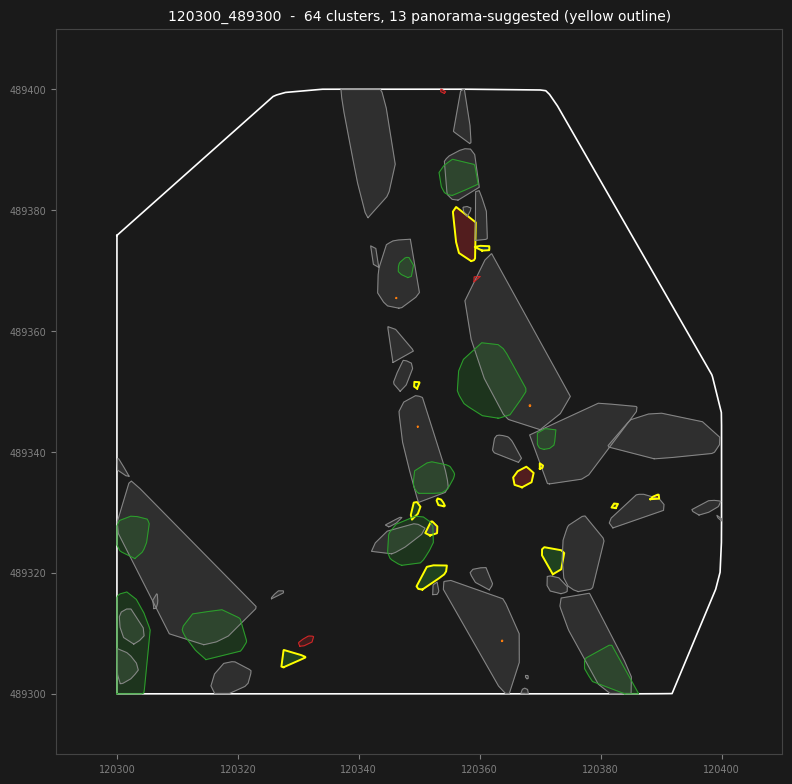

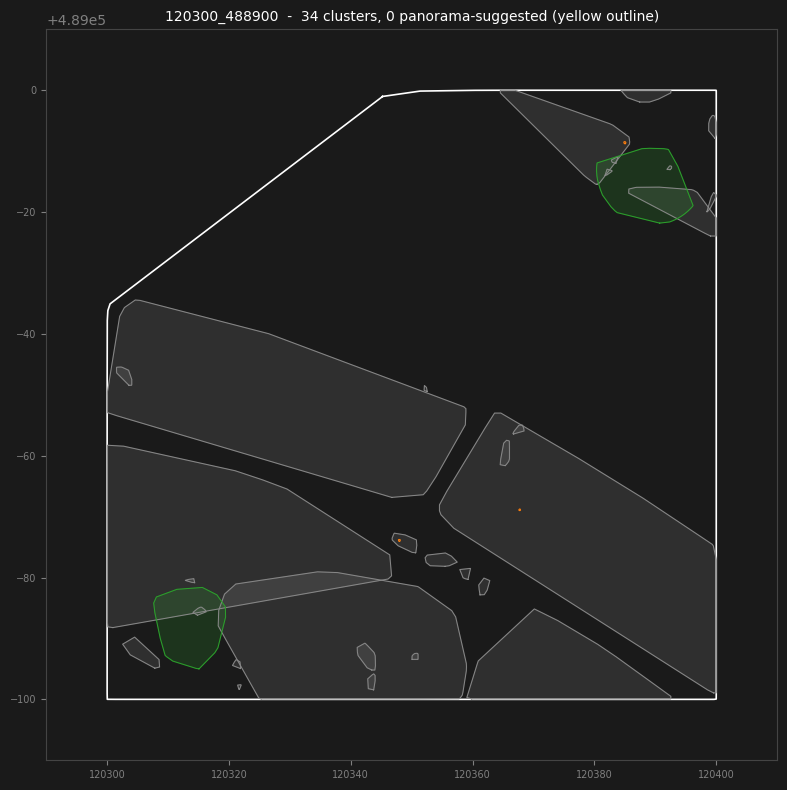

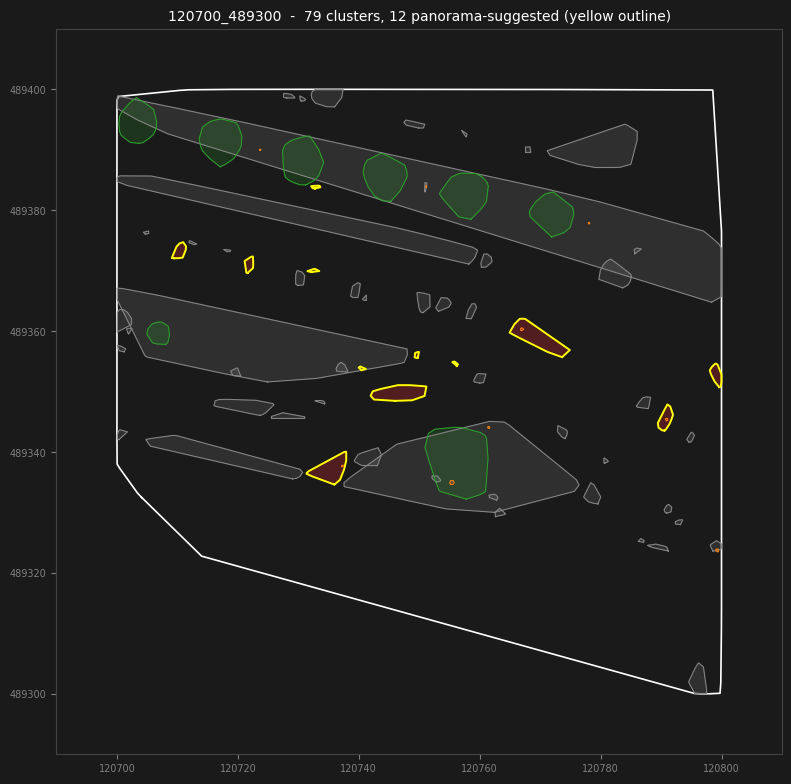

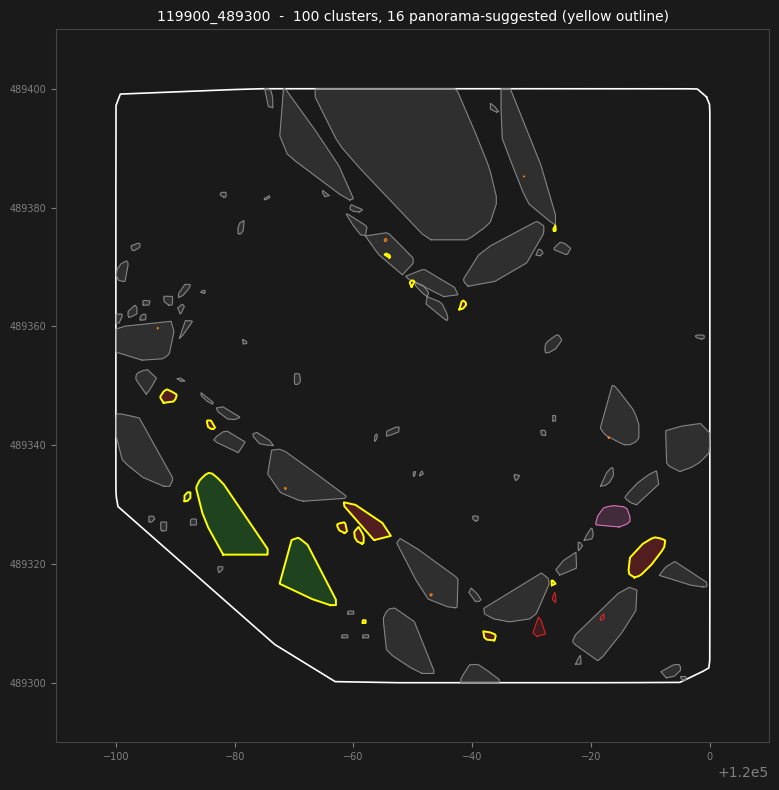

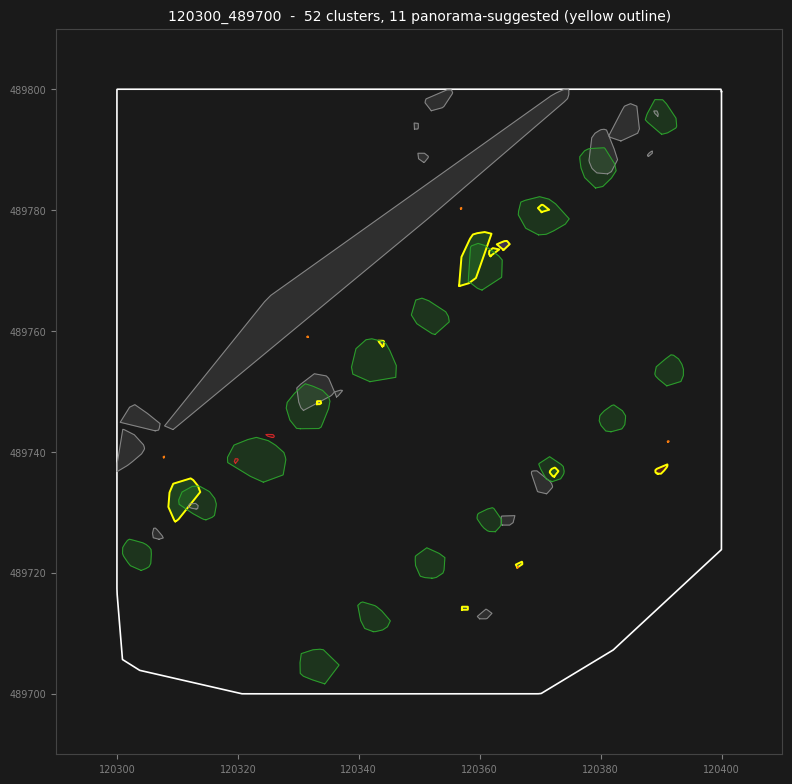

In [6]:
from shapely.geometry import shape

LABEL_COLORS = {
     0: '#888888', 30: '#2ca02c', 40: '#d62728', 44: '#1f77b4',
    46: '#17becf', 47: '#aec7e8', 45: '#bcbd22', 60: '#ff7f0e',
    65: '#7f7f7f', 80: '#9467bd', 81: '#8c564b', 83: '#e377c2',
    99: '#444444',
}

for tc in tilecodes:
    tile_inv = inventory[inventory['tilecode'] == tc]
    if len(tile_inv) == 0:
        continue

    bbox_path = config.BBOX_DIR / f"bbox_{tc}.geojson"
    if not bbox_path.exists():
        continue
    with open(bbox_path) as f:
        bbox_gj = json.load(f)
    tile_poly = shape(bbox_gj['features'][0]['geometry'])
    bx0, by0, bx1, by1 = tile_poly.bounds
    pad = 10

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('#1a1a1a')
    fig.patch.set_facecolor('#1a1a1a')

    tx, ty = tile_poly.exterior.xy
    ax.plot(tx, ty, 'w-', linewidth=1.2, zorder=2)

    for _, row in tile_inv.iterrows():
        npz_path = row['npz_path']
        if not Path(npz_path).exists():
            continue
        data = np.load(npz_path, allow_pickle=False)
        cx, cy = float(data['centroid_xy'][0]), float(data['centroid_xy'][1])
        xyz_c = data['xyz_centered'].astype(np.float32)
        pts2d = xyz_c[:, :2] + np.array([cx, cy], dtype=np.float32)

        lbl = int(row['label'])
        col = LABEL_COLORS.get(lbl, '#888888')
        is_pano = row.get('label_source') == 'panorama_yolo'

        from shapely.geometry import MultiPoint
        hull = MultiPoint(pts2d.astype(np.float64)).convex_hull
        edge_col = '#ffff00' if is_pano else col
        edge_w = 1.4 if is_pano else 0.7
        if hull.geom_type == 'Polygon':
            hx, hy = hull.exterior.xy
            ax.fill(hx, hy, color=col, alpha=0.30 if is_pano else 0.20, zorder=3)
            ax.plot(hx, hy, color=edge_col, linewidth=edge_w, zorder=4)
        else:
            ax.scatter(pts2d[:, 0], pts2d[:, 1], c=col, s=4, linewidths=0, zorder=3)

    ax.set_xlim(bx0 - pad, bx1 + pad)
    ax.set_ylim(by0 - pad, by1 + pad)
    ax.set_aspect('equal')
    n_pano = int((tile_inv['label_source'] == 'panorama_yolo').sum())
    ax.set_title(f'{tc}  -  {len(tile_inv)} clusters, {n_pano} panorama-suggested (yellow outline)',
                 color='white', fontsize=10)
    ax.tick_params(colors='grey', labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

    plt.tight_layout()
    plt.show()